In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:

class SimpleAttention(tf.keras.layers.Layer):
    def __init__(self):
         # obligatoire
         super().__init__()
         # ici : définir les attributs self.S, self.A, self.O (pour pouvoir les afficher...
         self.A=None
         self.O=None
         self.S=None

    def call(self, X,**kwargs):
     # recopier ici les calculs de l’étape précédente :
          S= X @ tf.transpose(X, perm=[0, 2, 1])
     # 2) A = ... (softmax ligne par ligne)
          A = tf.nn.softmax(S, axis=-1)

          O=A@X
          self.A=A
          self.O=O
          self.S=S
          return O

    def get_S(self):
     return self.S

    def get_A(self):
     return self.A

    def get_O(self):
     return self.O
#X = np.random.randn(10, 8)
#layer = SimpleAttention()
#O = layer(X)

#print(f"Taille de X : {X.shape}")
#print(f"Taille de O : {O.shape}")
#print(f"Ligne 3 de A : {layer.get_A()[3]}")
#print(f"Somme ligne 3 : {np.sum(layer.get_A()[3])}")

In [4]:
class MultiHeadSimpleAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim):
        super().__init__()
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.heads = [SimpleAttention() for _ in range(num_heads)]
        self.dense = tf.keras.layers.Dense(embed_dim)

    def call(self, X, training=False,**kwargs):
        outputs = [head(X) for head in self.heads]
        concat = tf.concat(outputs, axis=-1)
        return self.dense(concat)



In [5]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()

        self.att = MultiHeadSimpleAttention(
            num_heads,
            embed_dim
        )

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(embed_dim)
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, X, training=False,**kwargs):

        attn_output = self.att(X)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(X + attn_output)


        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [19]:
vocab = {
    "the":0, "apothecary":1, "diaries":2, "pride":3, "and":4, "prejudice":5, "naruto":6,
    "jojo":7, "bizarre":8, "adventures":9, "is":10, "a":11, "anime":12, "novel":13, "your":14,
    "name":15, "one":16, "piece":17, "harry":18, "potter":19, "stranger":20, "an":21, "best":22,
    "?":23, "isn't":24, "it":25, "barrier":26, ",":27, "of":28, "not":29, "great":30, "classic":31,
    "famous":32, "really":33, "just":34, "good":35, "written":36, "by":37, "camus":38, "austen":39,
    "about":40, "character":41, "story":42, "based":43, "on":44, "manga":45, "series":46, "book":47,
    "people":48, "love":49,
}

phrases = [
    "naruto is the best anime isn't it ?",
    "one piece is a really great anime ,",
    "jojo bizarre adventures is a great anime ,",
    "your name is a famous anime isn't it ?",
    "naruto is a famous anime series isn't it ?",
    "one piece is a classic anime series ,",
    "jojo bizarre adventures is the best anime",
    "the apothecary diaries is a great anime",
    "naruto is based on a great manga series",
    "one piece is based on a famous manga",
    "your name is just a really good anime",
    "jojo bizarre adventures is based on manga ,",
    "the apothecary diaries is not a novel ,",
    "naruto is not a novel it is anime",
    "one piece is not a novel it is anime",
    "pride and prejudice is the best novel ,",
    "harry potter is the best novel isn't it ?",
    "the stranger is a classic novel by camus",
    "pride and prejudice is written by austen ,",
    "harry potter is a famous novel series ,",
    "the stranger is a really good novel ,",
    "pride and prejudice is a classic novel ,",
    "harry potter is based on a great novel",
    "the stranger is not an anime it is novel",
    "pride and prejudice is not an anime ,",
    "harry potter is not anime it is a novel",
    "the stranger is a novel about one character",
    "pride and prejudice is a story about love",
    "harry potter is a novel people really love",
    "the stranger is the best novel by camus",
]



def tokeniser(phrase,vocab):
    mots=phrase.split()
    return [vocab[mot] for mot in mots]
X_sequences = []
y_labels = []

for phrase in phrases:
    tokens = tokeniser(phrase, vocab)
    for i in range(1, len(tokens)):
        sequence_contexte = tokens[:i]
        mot_a_deviner = tokens[i]

        X_sequences.append(sequence_contexte)
        y_labels.append(mot_a_deviner)

X = pad_sequences(X_sequences, maxlen=10, padding='pre')
y = np.array(y_labels)


split = int(0.9 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Nombre d'exemples d'entraînement créés : {len(X_train)}")
print(f"Nombre d'exemples de test créés : {len(X_test)}")
print(f"Exemple de X_train[0] : {X_train[0]}")
print(f"Exemple de y_train[0] (le mot à deviner) : {y_train[0]}")

Nombre d'exemples d'entraînement créés : 192
Nombre d'exemples de test créés : 22
Exemple de X_train[0] : [0 0 0 0 0 0 0 0 0 6]
Exemple de y_train[0] (le mot à deviner) : 10


In [27]:
vocab_size = len(vocab) + 1

embed_dim = 16
num_heads = 2
ff_dim    = 32

input = tf.keras.layers.Input(shape=(10,))
x = tf.keras.layers.Embedding(vocab_size, embed_dim)(input)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dropout(0.1)(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
x = tf.keras.layers.Dropout(0.1)(x)
x = tf.keras.layers.Dense(vocab_size, activation='softmax')(x)

model = tf.keras.Model(inputs=input, outputs=x)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [67]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=4,
    validation_data=(X_test, y_test)
)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8177 - loss: 0.4532 - val_accuracy: 0.4091 - val_loss: 8.1406
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8333 - loss: 0.4277 - val_accuracy: 0.4545 - val_loss: 8.1860
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7240 - loss: 0.6236 - val_accuracy: 0.3636 - val_loss: 8.0595
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7604 - loss: 0.5723 - val_accuracy: 0.4091 - val_loss: 8.0427
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7865 - loss: 0.4897 - val_accuracy: 0.4091 - val_loss: 8.0778
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7812 - loss: 0.4796 - val_accuracy: 0.3636 - val_loss: 8.3290
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7917 - loss: 0.5195 - val_accuracy: 0.4091 - val_loss: 7.9781
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7969 - loss: 0.5519 - val_accuracy: 0.4091 - val_los

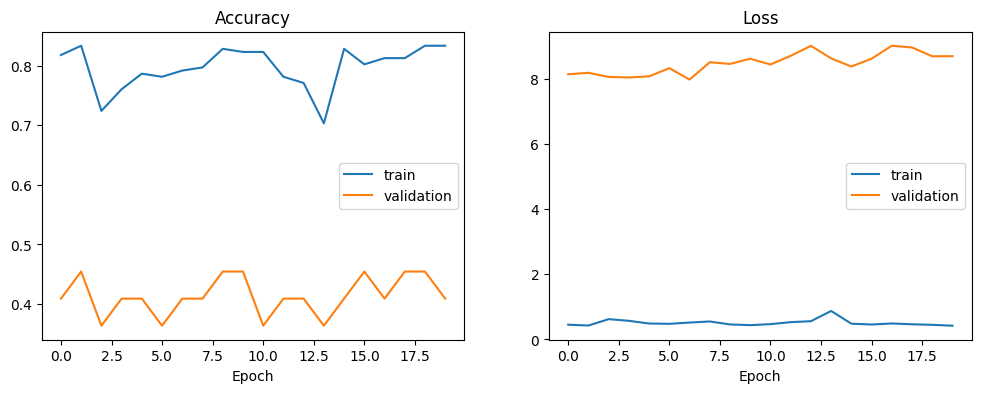

In [68]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Courbe Accuracy
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Courbe Loss
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

In [66]:


def prediction_mot_suivant(phrase_a_predire, nb_mots_a_predire):
    phrase = phrase_a_predire
    for _ in range(nb_mots_a_predire):
        tokens = tokeniser(phrase, vocab)
        tokens = pad_sequences([tokens], maxlen=10, padding='pre')

        prediction = model.predict(tokens, verbose=0)

        index_gagnant = np.argmax(prediction[0])

        mot_trouve = ""
        for mot, index in vocab.items():
            if index == index_gagnant:
                mot_trouve = mot
                break

        phrase += " " + mot_trouve
    return phrase

phrase_test = "naruto is"


print("\n--- TEST DE Prédiction ---")
resultat = prediction_mot_suivant(phrase_test,3)
print(f"phrase: '{phrase_test}'")
print(f"Résultat : -> {resultat}\n")



--- TEST DE GÉNÉRATION DE TEXTE ---
phrase: 'naruto is'
Résultat : -> naruto is best anime isn't

